In [1]:
import numpy as np

# Symbolic solution

## Autonomous System (2D)

In [4]:
x1, x2, mu= smp.symbols(r'x_1 x_2 \mu')

dx1 = x2
dx2 = -x1 + mu*x2*(1-x1**2) 

In [5]:

Jac = smp.Matrix([[smp.diff(dx1,x1),smp.diff(dx1,x2)],
                  [smp.diff(dx2,x1),smp.diff(dx2,x2)]])

Jac

Matrix([
[                 0,                1],
[-2*\mu*x_1*x_2 - 1, \mu*(1 - x_1**2)]])

In [6]:
J0 = Jac.subs([[x1,0],[x2,0],[mu,1]])
J0

Matrix([
[ 0, 1],
[-1, 1]])

In [7]:
J0.eigenvects()

[(1/2 - sqrt(3)*I/2,
  1,
  [Matrix([
   [1/2 + sqrt(3)*I/2],
   [                1]])]),
 (1/2 + sqrt(3)*I/2,
  1,
  [Matrix([
   [1/2 - sqrt(3)*I/2],
   [                1]])])]

In [8]:
ev1 = J0.eigenvects()[0][2][0]
ev2 = J0.eigenvects()[1][2][0]
ev1

Matrix([
[1/2 + sqrt(3)*I/2],
[                1]])

In [9]:

P = smp.Matrix([[ev1.T],
               [ev2.T]]).T
P

Matrix([
[1/2 + sqrt(3)*I/2, 1/2 - sqrt(3)*I/2],
[                1,                 1]])

In [10]:

s, u = smp.symbols('s u')

P_inv = P.inv()
su = smp.Matrix([s,u])
xy_dot = smp.Matrix([dx1,dx2])

In [11]:
trans = P@su
trans

Matrix([
[s*(1/2 + sqrt(3)*I/2) + u*(1/2 - sqrt(3)*I/2)],
[                                        s + u]])

In [12]:
su_dot = P_inv@xy_dot
su_dot

Matrix([
[x_2*(sqrt(3) - I)/(sqrt(3) + 3*I) - (\mu*x_2*(1 - x_1**2) - x_1)/(-3/2 + sqrt(3)*I/2)],
[                   sqrt(3)*I*x_2/3 + (1/2 - sqrt(3)*I/6)*(\mu*x_2*(1 - x_1**2) - x_1)]])

In [13]:
su_dot = su_dot.subs([[x1,trans[0]],
                       [x2,trans[1]]])

In [14]:
ds =  su_dot[0].expand()
du = su_dot[1].expand()

In [15]:
A = ds.coeff(s,1).coeff(u,0).coeff(mu,0)
A

sqrt(3)/(sqrt(3) + 3*I) + sqrt(3)*I/(-3 + sqrt(3)*I) + 1/(-3 + sqrt(3)*I) - I/(sqrt(3) + 3*I)

In [16]:
g1 = ds - A*s
g1

sqrt(3)*I*\mu*s**3/(-3 + sqrt(3)*I) - \mu*s**3/(-3 + sqrt(3)*I) + 3*\mu*s**2*u/(-3 + sqrt(3)*I) + sqrt(3)*I*\mu*s**2*u/(-3 + sqrt(3)*I) + 3*\mu*s*u**2/(-3 + sqrt(3)*I) - sqrt(3)*I*\mu*s*u**2/(-3 + sqrt(3)*I) - \mu*s/(-3/2 + sqrt(3)*I/2) - \mu*u**3/(-3 + sqrt(3)*I) - sqrt(3)*I*\mu*u**3/(-3 + sqrt(3)*I) - \mu*u/(-3/2 + sqrt(3)*I/2) + sqrt(3)*s/(sqrt(3) + 3*I) + sqrt(3)*I*s/(-3 + sqrt(3)*I) + s/(-3 + sqrt(3)*I) - I*s/(sqrt(3) + 3*I) - s*(sqrt(3)/(sqrt(3) + 3*I) + sqrt(3)*I/(-3 + sqrt(3)*I) + 1/(-3 + sqrt(3)*I) - I/(sqrt(3) + 3*I)) + sqrt(3)*u/(sqrt(3) + 3*I) + u/(-3 + sqrt(3)*I) - I*u/(sqrt(3) + 3*I) - sqrt(3)*I*u/(-3 + sqrt(3)*I)

In [17]:
B = du.coeff(s,0).coeff(u,1).coeff(mu,0)
B

2*sqrt(3)*I/3

In [18]:
g2 = du - B*u

g2

-sqrt(3)*I*\mu*s**3/3 - \mu*s**2*u - \mu*s*u**2/2 + sqrt(3)*I*\mu*s*u**2/2 + \mu*s/2 - sqrt(3)*I*\mu*s/6 + \mu*u**3/2 + sqrt(3)*I*\mu*u**3/6 + \mu*u/2 - sqrt(3)*I*\mu*u/6 - s/2 + sqrt(3)*I*s/6

In [19]:
k1, k2, k3 = smp.symbols(r'\kappa_1 \kappa_2 \kappa_3')

h = k1*s**2 + k2*s*mu + k3*mu**2

Dh = smp.diff(h,s)

In [20]:
N = Dh*(A*s + g1) - B*h - g2
N = N.subs(u,h).expand()
N

-2*\kappa_1**4*\mu*s**7/(-3 + sqrt(3)*I) - 2*sqrt(3)*I*\kappa_1**4*\mu*s**7/(-3 + sqrt(3)*I) - 7*\kappa_1**3*\kappa_2*\mu**2*s**6/(-3 + sqrt(3)*I) - 7*sqrt(3)*I*\kappa_1**3*\kappa_2*\mu**2*s**6/(-3 + sqrt(3)*I) - 6*\kappa_1**3*\kappa_3*\mu**3*s**5/(-3 + sqrt(3)*I) - 6*sqrt(3)*I*\kappa_1**3*\kappa_3*\mu**3*s**5/(-3 + sqrt(3)*I) - \kappa_1**3*\mu*s**6/2 + 6*\kappa_1**3*\mu*s**6/(-3 + sqrt(3)*I) - sqrt(3)*I*\kappa_1**3*\mu*s**6/6 - 2*sqrt(3)*I*\kappa_1**3*\mu*s**6/(-3 + sqrt(3)*I) - 9*\kappa_1**2*\kappa_2**2*\mu**3*s**5/(-3 + sqrt(3)*I) - 9*sqrt(3)*I*\kappa_1**2*\kappa_2**2*\mu**3*s**5/(-3 + sqrt(3)*I) - 15*\kappa_1**2*\kappa_2*\kappa_3*\mu**4*s**4/(-3 + sqrt(3)*I) - 15*sqrt(3)*I*\kappa_1**2*\kappa_2*\kappa_3*\mu**4*s**4/(-3 + sqrt(3)*I) - 3*\kappa_1**2*\kappa_2*\mu**2*s**5/2 + 15*\kappa_1**2*\kappa_2*\mu**2*s**5/(-3 + sqrt(3)*I) - sqrt(3)*I*\kappa_1**2*\kappa_2*\mu**2*s**5/2 - 5*sqrt(3)*I*\kappa_1**2*\kappa_2*\mu**2*s**5/(-3 + sqrt(3)*I) - 6*\kappa_1**2*\kappa_3**2*\mu**5*s**3/(-3 + sqrt

In [21]:
N.coeff(s,0).coeff(mu,0)

0

In [22]:
N.coeff(s,1).coeff(mu,0)

1/2 - sqrt(3)*I/6

In [23]:
N.coeff(s,2).coeff(mu,0)

-2*sqrt(3)*I*\kappa_1/3 + 2*sqrt(3)*\kappa_1/(sqrt(3) + 3*I) + 2*sqrt(3)*I*\kappa_1/(-3 + sqrt(3)*I) + 2*\kappa_1/(-3 + sqrt(3)*I) - 2*I*\kappa_1/(sqrt(3) + 3*I)

In [24]:
N.coeff(s,0).coeff(mu,1)

0

In [25]:
N.coeff(s,0).coeff(mu,2)

-2*sqrt(3)*I*\kappa_3/3

In [26]:
N.coeff(s,1).coeff(mu,1)

-2*sqrt(3)*I*\kappa_2/3 + sqrt(3)*\kappa_2/(sqrt(3) + 3*I) + sqrt(3)*I*\kappa_2/(-3 + sqrt(3)*I) + \kappa_2/(-3 + sqrt(3)*I) - I*\kappa_2/(sqrt(3) + 3*I) - 1/2 + sqrt(3)*I/6

## Non-Autonomous System (3D)

In [69]:
x1, x2, mu, w, t, alp, F= smp.symbols(r'x_1 x_2 \mu \omega t \alpha \mathcal{F}')

# sin = (w*t) - (w*t)**3/(3*2) #+ (w*t)**5/(5*4*3*2) - (w*t)**7/(7*6*5*4*3*2) 

w = 1.2
alp = 0


dx1 = x2
dx2 = -x1 + mu*x2*(1-x1**2) + alp*smp.sin(w*t)
dt = 1

### Jacobian about origin

In [ ]:
# Jac = smp.Matrix([[smp.diff(dx1,x1),smp.diff(dx1,x2),smp.diff(dx1,t)],
#                   [smp.diff(dx2,x1),smp.diff(dx2,x2),smp.diff(dx2,t)],
#                   [smp.diff(dt,x1),smp.diff(dt,x2),smp.diff(dt,t)]])

Matrix([
[                 0,                1],
[-2*\mu*x_1*x_2 - 1, \mu*(1 - x_1**2)]])

In [71]:
J0 = Jac.subs([[x1,0],[x2,0],[mu,1]])
J0

Matrix([
[ 0, 1],
[-1, 1]])

In [72]:
J0.eigenvects()

[(1/2 - sqrt(3)*I/2,
  1,
  [Matrix([
   [1/2 + sqrt(3)*I/2],
   [                1]])]),
 (1/2 + sqrt(3)*I/2,
  1,
  [Matrix([
   [1/2 - sqrt(3)*I/2],
   [                1]])])]

In [65]:
J0.eigenvals()

{0: 1, 1/2 - sqrt(3)*I/2: 1, 1/2 + sqrt(3)*I/2: 1}

### Transform

In [73]:
ev1 = J0.eigenvects()[0][2][0]
ev2 = J0.eigenvects()[1][2][0]
# ev3 = J0.eigenvects()[2][2][0]
ev1

Matrix([
[1/2 + sqrt(3)*I/2],
[                1]])

In [ ]:
# P = smp.Matrix([[ev1.T],
#                [ev2.T],
#                [ev3.T]]).T

Matrix([
[1/2 + sqrt(3)*I/2, 1/2 - sqrt(3)*I/2],
[                1,                 1]])

In [ ]:
# c, s, u = smp.symbols('c s u')

# P_inv = P.inv()
# csu = smp.Matrix([c,s,u])
# xyt_dot = smp.Matrix([dx1,dx2,dt])

In [ ]:
# trans = P@csu


Matrix([
[s*(1/2 + sqrt(3)*I/2) + u*(1/2 - sqrt(3)*I/2)],
[                                        s + u]])

In [77]:
su_dot = P_inv@xy_dot
su_dot

Matrix([
[x_2*(sqrt(3) - I)/(sqrt(3) + 3*I) - (\mu*x_2*(1 - x_1**2) - x_1)/(-3/2 + sqrt(3)*I/2)],
[                   sqrt(3)*I*x_2/3 + (1/2 - sqrt(3)*I/6)*(\mu*x_2*(1 - x_1**2) - x_1)]])

In [79]:
su_dot = su_dot.subs([[x1,trans[0]],
                       [x2,trans[1]]])

### Manifold

In [81]:
# dc = csu_dot[0].expand()
ds =  su_dot[0].expand()
du = su_dot[1].expand()

In [88]:
# A = dc.coeff(c,1).coeff(s,0).coeff(u,0).coeff(alp,0)
A = ds.coeff(s,1).coeff(u,0).coeff(mu,0)
A

sqrt(3)/(sqrt(3) + 3*I) + sqrt(3)*I/(-3 + sqrt(3)*I) + 1/(-3 + sqrt(3)*I) - I/(sqrt(3) + 3*I)

In [89]:
g1 = ds - A*s
g1

sqrt(3)*I*\mu*s**3/(-3 + sqrt(3)*I) - \mu*s**3/(-3 + sqrt(3)*I) + 3*\mu*s**2*u/(-3 + sqrt(3)*I) + sqrt(3)*I*\mu*s**2*u/(-3 + sqrt(3)*I) + 3*\mu*s*u**2/(-3 + sqrt(3)*I) - sqrt(3)*I*\mu*s*u**2/(-3 + sqrt(3)*I) - \mu*s/(-3/2 + sqrt(3)*I/2) - \mu*u**3/(-3 + sqrt(3)*I) - sqrt(3)*I*\mu*u**3/(-3 + sqrt(3)*I) - \mu*u/(-3/2 + sqrt(3)*I/2) + sqrt(3)*s/(sqrt(3) + 3*I) + sqrt(3)*I*s/(-3 + sqrt(3)*I) + s/(-3 + sqrt(3)*I) - I*s/(sqrt(3) + 3*I) - s*(sqrt(3)/(sqrt(3) + 3*I) + sqrt(3)*I/(-3 + sqrt(3)*I) + 1/(-3 + sqrt(3)*I) - I/(sqrt(3) + 3*I)) + sqrt(3)*u/(sqrt(3) + 3*I) + u/(-3 + sqrt(3)*I) - I*u/(sqrt(3) + 3*I) - sqrt(3)*I*u/(-3 + sqrt(3)*I)

In [90]:
# b1 = ds.coeff(c,0).coeff(s,1).coeff(u,0).coeff(alp,0)
# b2 = du.coeff(c,0).coeff(s,0).coeff(u,1).coeff(alp,0)

# B = smp.Matrix([[b1,0],
#                 [0,b2]])
B = du.coeff(s,0).coeff(u,1).coeff(mu,0)
B

2*sqrt(3)*I/3

In [91]:
# g2_1 = ds - b1*s
# g2_2 = du - b2*u
# g2 = smp.Matrix([g2_1,g2_2])

g2 = du - B*u

g2

-sqrt(3)*I*\mu*s**3/3 - \mu*s**2*u - \mu*s*u**2/2 + sqrt(3)*I*\mu*s*u**2/2 + \mu*s/2 - sqrt(3)*I*\mu*s/6 + \mu*u**3/2 + sqrt(3)*I*\mu*u**3/6 + \mu*u/2 - sqrt(3)*I*\mu*u/6 - s/2 + sqrt(3)*I*s/6

In [101]:
k1, k2, k3, b1, b2, b3 = smp.symbols(r'\kappa_1 \kappa_2 \kappa_3 \beta_1 \beta_2 \beta_3')

h1 = k1*s**2 + k2*s*mu + k3*mu**2
# h2 = b1*c**2 + b2*c*alp + b3*alp**2

H = h1#smp.Matrix([h1,h2])
Dh = smp.diff(H,s)

In [102]:
N = Dh*(A*s + g1) - B*H - g2
N = N.subs(u,H).expand()
N

-2*\kappa_1**4*\mu*s**7/(-3 + sqrt(3)*I) - 2*sqrt(3)*I*\kappa_1**4*\mu*s**7/(-3 + sqrt(3)*I) - 7*\kappa_1**3*\kappa_2*\mu**2*s**6/(-3 + sqrt(3)*I) - 7*sqrt(3)*I*\kappa_1**3*\kappa_2*\mu**2*s**6/(-3 + sqrt(3)*I) - 6*\kappa_1**3*\kappa_3*\mu**3*s**5/(-3 + sqrt(3)*I) - 6*sqrt(3)*I*\kappa_1**3*\kappa_3*\mu**3*s**5/(-3 + sqrt(3)*I) - \kappa_1**3*\mu*s**6/2 + 6*\kappa_1**3*\mu*s**6/(-3 + sqrt(3)*I) - sqrt(3)*I*\kappa_1**3*\mu*s**6/6 - 2*sqrt(3)*I*\kappa_1**3*\mu*s**6/(-3 + sqrt(3)*I) - 9*\kappa_1**2*\kappa_2**2*\mu**3*s**5/(-3 + sqrt(3)*I) - 9*sqrt(3)*I*\kappa_1**2*\kappa_2**2*\mu**3*s**5/(-3 + sqrt(3)*I) - 15*\kappa_1**2*\kappa_2*\kappa_3*\mu**4*s**4/(-3 + sqrt(3)*I) - 15*sqrt(3)*I*\kappa_1**2*\kappa_2*\kappa_3*\mu**4*s**4/(-3 + sqrt(3)*I) - 3*\kappa_1**2*\kappa_2*\mu**2*s**5/2 + 15*\kappa_1**2*\kappa_2*\mu**2*s**5/(-3 + sqrt(3)*I) - sqrt(3)*I*\kappa_1**2*\kappa_2*\mu**2*s**5/2 - 5*sqrt(3)*I*\kappa_1**2*\kappa_2*\mu**2*s**5/(-3 + sqrt(3)*I) - 6*\kappa_1**2*\kappa_3**2*\mu**5*s**3/(-3 + sqrt

In [103]:
N1 = N
# N2 = N[1]

In [104]:
N1_c_pow2   = N1.coeff(s,2).coeff(mu,0)
N1_c_pow1   = N1.coeff(s,1).coeff(mu,0)
N1_c_alp    = N1.coeff(s,1).coeff(mu,1)
N1_alp_pow1 = N1.coeff(s,0).coeff(mu,1)
N1_alp_pow2 = N1.coeff(s,0).coeff(mu,2)

# N2_c_pow2   = N2.coeff(c,2).coeff(alp,0)
# N2_c_pow1   = N2.coeff(c,1).coeff(alp,0)
# N2_c_alp    = N2.coeff(c,1).coeff(alp,1)
# N2_alp_pow1 = N2.coeff(c,0).coeff(alp,1)
# N2_alp_pow2 = N2.coeff(c,0).coeff(alp,2)

In [105]:
N1_c_pow1

1/2 - sqrt(3)*I/6

In [106]:
N1_alp_pow1

0

In [117]:
k2_sub = smp.solve(N1_alp_pow1,k2)[0]
b2_sub = smp.solve(N2_alp_pow1,b2)[0]

In [106]:
N1_c_pow2.subs([[b1,0],[k1,0]])

0

In [118]:
N1_c_alp = N1_c_alp.subs([[b1,0],[k1,0],[k2,k2_sub],[b2,b2_sub]])
N1_c_alp

-\omega/2 - sqrt(3)*I*\omega/6

In [119]:
N1_alp_pow2 = N1_alp_pow2.subs([[b1,0],[k1,0],[k2,k2_sub],[b2,b2_sub]])
N1_alp_pow2

-\beta_3*\mu/2 - sqrt(3)*I*\beta_3*\mu/6 + \beta_3/2 + sqrt(3)*I*\beta_3/6 - \kappa_3*\mu/2 - sqrt(3)*I*\kappa_3*\mu/6 + 2*sqrt(3)*I*\kappa_3/3

In [120]:
N2_c_pow2 = N2_c_pow2.subs([[b1,0],[k1,0],[k2,k2_sub],[b2,b2_sub]])
N2_c_pow2

0

In [121]:
N2_c_alp = N2_c_alp.subs([[b1,0],[k1,0],[k2,k2_sub],[b2,b2_sub]])
N2_c_alp

-\omega/2 + sqrt(3)*I*\omega/6

In [131]:
N2_alp_pow2 = N2_alp_pow2.subs([[b1,0],[k1,0],[k2,k2_sub],[b2,b2_sub]])
N2_alp_pow2

-\beta_3*\mu/2 + sqrt(3)*I*\beta_3*\mu/6 - \beta_3*\mu*(-sqrt(3)*\mu + 3*I*\mu + sqrt(3) - 3*I)/(2*(sqrt(3)*\mu - 3*I*\mu - 4*sqrt(3))) + sqrt(3)*I*\beta_3*\mu*(-sqrt(3)*\mu + 3*I*\mu + sqrt(3) - 3*I)/(6*(sqrt(3)*\mu - 3*I*\mu - 4*sqrt(3))) - 2*sqrt(3)*I*\beta_3/3 + \beta_3*(-sqrt(3)*\mu + 3*I*\mu + sqrt(3) - 3*I)/(2*(sqrt(3)*\mu - 3*I*\mu - 4*sqrt(3))) - sqrt(3)*I*\beta_3*(-sqrt(3)*\mu + 3*I*\mu + sqrt(3) - 3*I)/(6*(sqrt(3)*\mu - 3*I*\mu - 4*sqrt(3)))

In [132]:
smp.solve([N1_alp_pow2,N2_alp_pow2],[k3,b3])

{\beta_3: 0, \kappa_3: 0}

In [133]:
smp.solve([N1_c_alp,N2_c_alp],[w])

{\omega: 0}

In [44]:
N2.subs([[k1,0],
        [k2,0],
        [k3,0]])

-1

In [159]:
dx1_f = smp.lambdify([x1,x2,t,mu,alp,w],dx1)
dx2_f = smp.lambdify([x1,x2,t,mu,alp,w],dx2)

In [160]:
x1v = np.linspace(-10,10,20)/2
x2v = np.linspace(-10,10,20)/2

x1G, x2G = np.meshgrid(x1v,x2v)

In [183]:
mu_val = 1
w_val = 1.2
a_val = 0
F_val = np.linspace(0,1,25)
t_val = np.linspace(0,10*np.pi,1000)

In [3]:
import sympy as smp

# Numerical solution

In [2]:
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from ipywidgets import interact

In [3]:
clr = ['cornflowerblue',
      'gold',
      'tomato',
      'dimgray']

Eigenvalue pair

$$\frac{\mu}{2} \pm \frac{\sqrt{(\mu - 2)*(\mu + 2)}}{2}$$

When $\mu=1$

$$\frac{1}{2} \pm \frac{\sqrt{3}}{2}\mathcal{i}$$

In [4]:
class vanDerPol:
    
    clr = ['cornflowerblue',
      'gold',
      'tomato',
      'dimgray']
    
    def __init__(self, mu, Af, wf):
        self.mu = mu
        self.Af = Af
        self.wf = wf
        self.soln = None
        self.T = None
        self.limC = None
        self.poinSec = None

    def drive(self,t):
        return self.Af*np.sin(self.wf*t) 
        
    def dif_Eq(self,X,t):
        x1, x2 = X

        dx1 = x2
        dx2 = self.mu*x2*(1-x1**2)-x1 + self.drive(t) #self.Af*np.sin(self.wf*t)

        return [dx1,dx2]

    
    
    def simulate(self,x0,t):
        S = odeint(self.dif_Eq,x0,t).T
        self.soln = [S,t]
        # return self.soln



    def get_limCycle(self,plot =False):
        x, y = self.soln[0]
        t = self.soln[1]
        
        dx = np.diff(x)
        idx = np.where(dx<=0)[0]
        jump = np.where(np.diff(idx)>1)[0]
        idx = idx[jump+1]
        theta0 = idx[-3]
        thetaf = idx[-2]
        self.T = t[thetaf] - t[theta0]
        self.limC = [x[theta0:thetaf],y[theta0:thetaf]]

        if plot ==True:
            plt.plot(self.limC[0],self.limC[1])
            plt.grid()
            plt.title(f'Limit Cycle, with period: {np.round(self.T,3)}')

        
    def plt_sim(self):
        x, y = self.soln[0]
        t = self.soln[1]
            
        fig = plt.figure(figsize=(14,6))
        
        gs = gridspec.GridSpec(1,4)
        
        p1 = fig.add_subplot(gs[:3])
        p2 = fig.add_subplot(gs[3:])
        
        
        p1.plot(t,x,color=clr[0],label=r'$\dot x_1$')
        p1.plot(t,y,color=clr[1],label=r'$\dot x_2$')
        p1.plot(t,self.drive(t),color=clr[2],label=r'$F(t)$')
        p1.grid()
        # p1.plot(self.t,kick(t,kick_time[0],0),color=clr[-1],label=r'$\delta(t)$')
        
        
        
        p1.legend()
        
        p2.plot(x,y)
        p2.grid()
        # p2.set_xlim([1.8,2.1])
        # p2.set_ylim([-0.5,0.5])
        # p2.vlines(0,ymin=ylim[0],ymax=ylim[1],color=clr[-1],linestyle='--')
        
    
    
    def comp_poincar(self):
        x,y = self.soln[0]
        t = self.soln[1]
        diff = np.diff(x**2)
        pos = np.where(diff>=0)[0]

        idx = pos

        gap = np.where(np.diff(idx)>1)[0]
        idx = idx[gap+1]

        y_map = y[idx]

        pos = np.where(y_map>0)[0]

        idx = idx[pos]
        x_map = x[idx]
        y_map = y[idx]
        t_map = t[idx]

        t_map = self.drive(t_map)/self.Af
        
        self.poinSec = [t_map,y_map,x_map]
        
        return self.poinSec
        
        
        
    def plt_poincar(self):
        if self.poinSec==None:
            t,y,x = self.comp_poincar()
        else:
            t,y,x = self.poinSec
        
        plt.scatter(t,y)
        plt.grid()
        

### Test case

In [5]:
vdp_test = vanDerPol(mu = 0.1,
                    Af = 0,
                    wf = 2*np.pi)

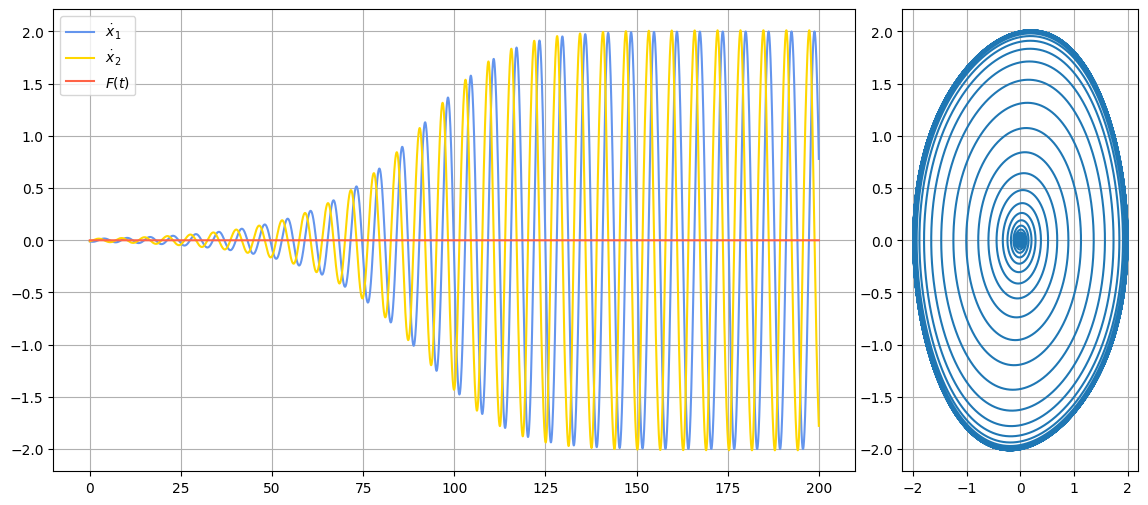

In [7]:
t = np.linspace(0,200,100000)
x0 = [-0.01,-0.01]

vdp_test.simulate(x0,t)
vdp_test.plt_sim()

In [8]:
vdp_test.get_limCycle()

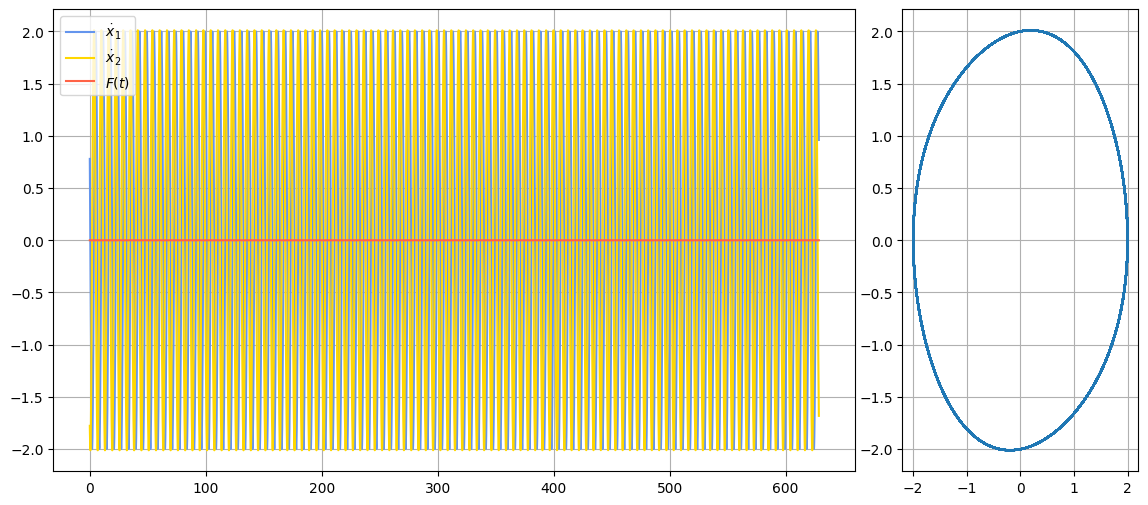

In [9]:
t = np.linspace(0,100*vdp_test.T,10000)
x,y = vdp_test.soln[0]
x0 = [x[-1],y[-1]]

vdp_test.simulate(x0,t)
vdp_test.plt_sim()

In [18]:
gamma = vdp_test.limC

### No Forcing

In [47]:
vdp_A0 = vanDerPol(1,0,0)

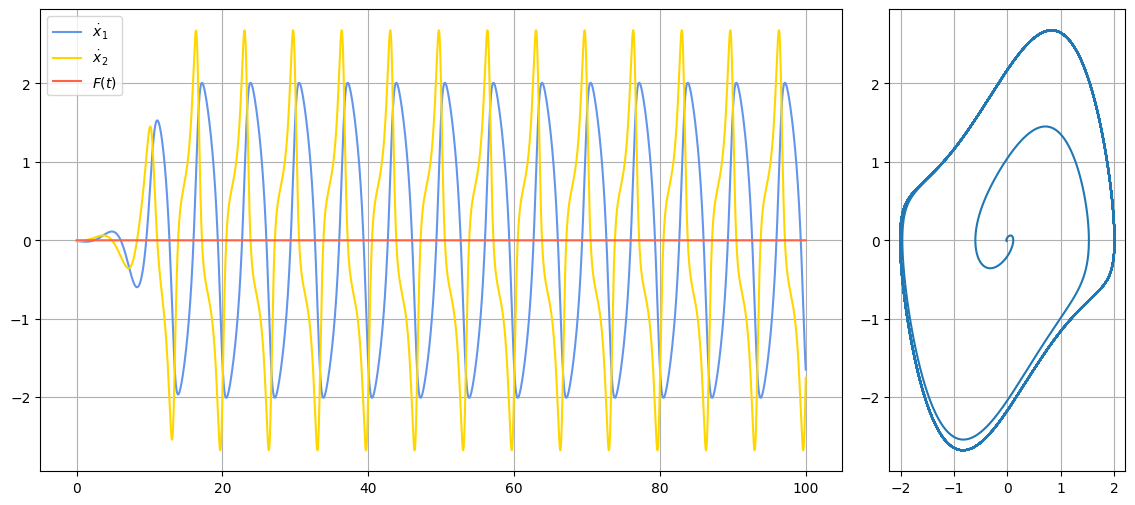

In [48]:
t = np.linspace(0,100,100000)
x0 = [-0.01,-0.01]
vdp_A0.simulate(x0,t)
vdp_A0.plt_sim()

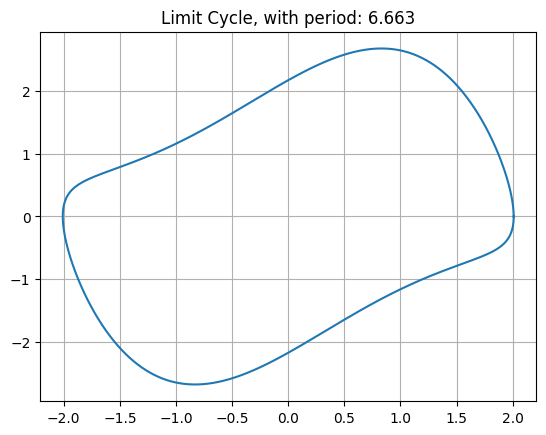

In [33]:
vdp_A0.get_limCycle(plot=True)

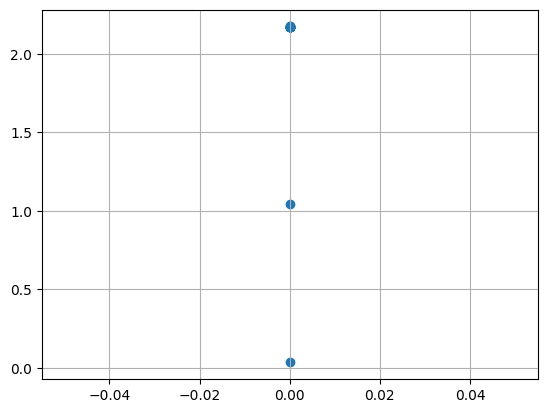

In [34]:
vdp_A0.plt_poincar()

### Small Forcing

In [41]:
vdp_A03 = vanDerPol(mu = 1,
                    Af = 0.3,
                    wf = 1.2)

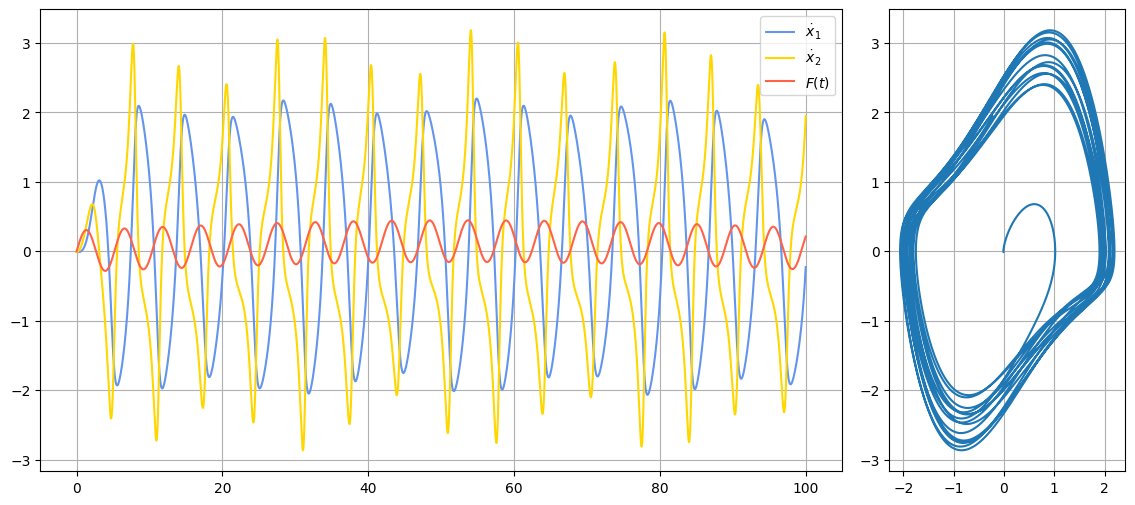

In [42]:
t = np.linspace(0,100,100000)
x0 = [-0.01,-0.01]

vdp_A03.simulate(x0,t)
vdp_A03.plt_sim()

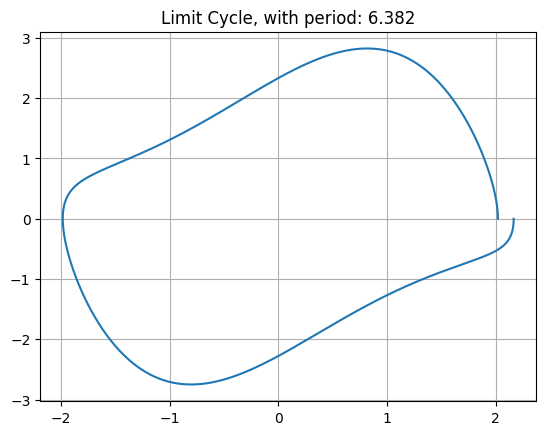

In [43]:
vdp_A03.get_limCycle(plot=True)

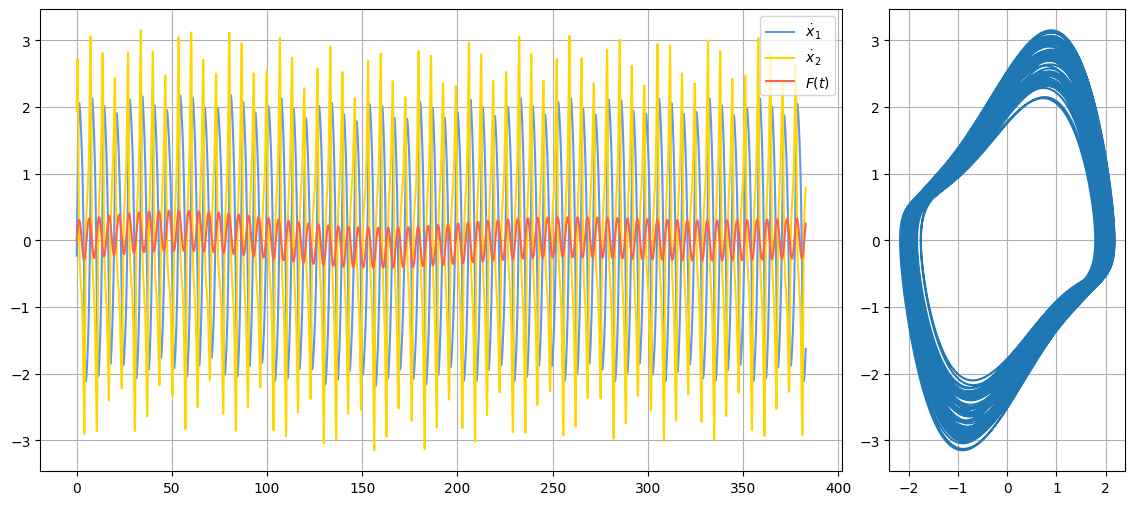

In [44]:
t = np.linspace(0,60*vdp_A03.T,100000)
x,y = vdp_A03.soln[0]
x0 = [x[-1],y[-1]]

vdp_A03.simulate(x0,t)
vdp_A03.plt_sim()

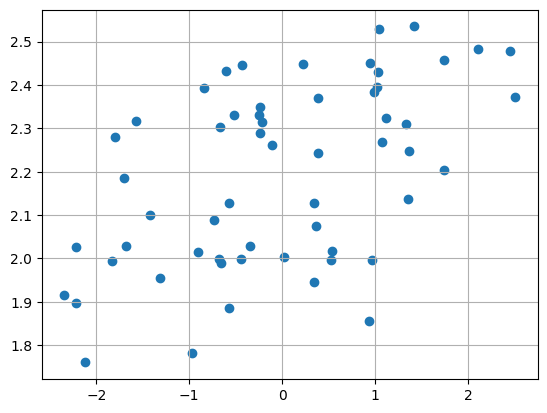

In [45]:
vdp_A03.plt_poincar()

### Adjoint

In [16]:
def Adj(X):
    x,y = X
    mu = 1
    A = np.array([[0,1],[-1-2*mu*x*y,mu*(1-x**2)]])

In [17]:
Adj(cyc)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 2 dimensions. The detected shape was (2, 2) + inhomogeneous part.